# 1. Импорты 

In [1]:
import sys
import os

# Сохраняем оригинальную директорию
original_dir = os.getcwd()

# Меняем директорию на родительскую
os.chdir(os.path.dirname(original_dir))

In [2]:
os.getcwd()

'/mnt/c/Jupyter-projects/mag_ML2'

## Свои скрипты

In [25]:
from core.config import Settings

settings = Settings()
settings

Settings(robot=RobotSettings(wheel_radius=0.04, theta=0.5235987755982988, wheel_mounting_radius=0.125), data_path=DataPath(train_val_dir='data/raw/Data_Set_(A+B).xlsx', test_dir='data/raw/Data_Set_C.xlsx', report_dir_raw='reports/raw/', report_dir_scaled='reports/scaled/', report_dir_balanced='reports/balanced/'))

## Библиотеки

In [88]:
import pandas as pd
import numpy as np

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import MinMaxScaler


%matplotlib inline
import matplotlib.pyplot as plt

# 2. Работа с данными

In [5]:
df = pd.read_excel(settings.data_path.train_val_dir)
df

,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,V2real,V3real,N1,N2,N3,Type
0,1.126697,0.021116,0.927601,0.712941,-0.252941,1.081765,0.043529,0.003174,0.011661,-249.352941,4.764706,265.235294,-5070,30,5239,1
1,1.039215,0.015083,0.953243,0.229412,0.276471,0.485294,0.013672,-0.005572,0.012164,-260.470588,0.000000,263.647059,-5320,-9,5391,1
2,0.911011,0.004525,0.947210,1.170588,0.222941,0.664118,0.011704,0.003720,0.005744,-268.411765,0.000000,268.411765,-4829,6,4786,1
3,0.692308,1.156862,0.550528,1.165294,0.698235,-3.421765,0.001321,-0.010311,-0.001522,141.352941,-306.529412,162.000000,2670,-5662,2875,1
4,0.529412,1.024133,0.453997,0.808235,0.090000,-1.449412,0.006218,-0.010986,-0.006247,155.647059,-314.470588,169.941176,2841,-5824,2967,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,0.288889,0.449573,0.270085,0.153333,-2.288667,40.140000,-0.019906,0.003939,-0.000586,349.200000,340.200000,358.200000,5847,5663,5901,5
172,0.314530,0.331624,0.341880,0.096000,-2.154667,37.425333,-0.015479,0.000993,-0.009017,347.400000,343.800000,360.000000,6025,6018,6005,5
173,0.287179,0.377778,0.391453,-1.820667,-5.030000,82.963333,0.027490,0.046403,-0.012874,750.600000,739.800000,738.000000,12100,12073,12049,5
174,0.370940,0.427350,0.336752,-0.624000,-4.574000,83.285333,0.014160,-0.043896,0.003906,734.400000,745.200000,747.000000,12493,12493,12564,5


In [6]:
df['Type'] = (df['Type'] == 4).astype(int)

In [7]:
class RobotKinematicsProcessor:
    def __init__(self):
        self.theta: float = settings.robot.theta
        self.L: float = settings.robot.wheel_mounting_radius
        self.R: float = settings.robot.wheel_radius
    
    def calc_vel(
        self,
        omega_vec: np.ndarray,
        alpha:float,
    ) -> np.ndarray:
        return self.R * self._kinemaitc_mat_vel(alpha=alpha) * omega_vec
    
    def calc_current(
        self,
        current_vec: np.ndarray,
        alpha: float,
    ) -> np.ndarray:
        return self._kinemaitc_mat_current(alpha=alpha) * current_vec
    
    def _kinemaitc_mat_vel(
        self,
        alpha: float,
        ) -> np.ndarray:
        
        return np.array([
            [-2/3 * np.cos(alpha - self.theta), 2/3 * np.sin(alpha), 2/3 * np.cos(alpha + self.theta)],
            [-2/3 * np.cos(alpha - self.theta), 2/3 * np.sin(alpha), 2/3 * np.cos(alpha + self.theta)],
            [1 / (3 * self.L), 1 / (3 * self.L), 1 / (3 * self.L)]
        ])
        
    def _kinemaitc_mat_current(
        self,
        alpha: float,
        ) -> np.ndarray:
        
        return np.array([
            [-2/3 * np.cos(alpha - self.theta), 2/3 * np.sin(alpha), 2/3 * np.cos(alpha + self.theta)],
            [-2/3 * np.cos(alpha - self.theta), 2/3 * np.sin(alpha), 2/3 * np.cos(alpha + self.theta)],
            [1/3, 1/3, 1/3]
        ])

In [8]:
kinematics_processor = RobotKinematicsProcessor()

In [ ]:
def process_row(row):
    # Собираем векторы из столбцов
    omega = np.array([row['N1'], row['N2'], row['N3']])
    currents = np.array([row['I1'], row['I2'], row['I3']])
    
    # Здесь нужно определить alpha. Допустим, alpha = 0
    alpha = 0.0 
    
    # Считаем
    # .flatten() нужен, чтобы превратить результат матричного умножения в плоский массив
    vel_res = kinematics_processor.calc_vel(omega, alpha).flatten()
    curr_res = kinematics_processor.calc_current(currents, alpha).flatten()
    
    # Возвращаем новые значения как Series
    return pd.Series({
        'vx': vel_res[0], 'vy': vel_res[1], 'v_omega': vel_res[2],
        'curr_x': curr_res[0], 'curr_y': curr_res[1], 'curr_total': curr_res[2]
    })

# Применяем функцию к DataFrame
new_columns = df.apply(process_row, axis=1)

# Соединяем с исходным DF
df = pd.concat([df, new_columns], axis=1)

In [10]:
df

,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,...,N1,N2,N3,Type,vx,vy,v_omega,curr_x,curr_y,curr_total
0,1.126697,0.021116,0.927601,0.712941,-0.252941,1.081765,0.043529,0.003174,0.011661,-249.352941,...,-5070,30,5239,0,117.086635,0.0,120.989522,-0.650499,0.0,0.535551
1,1.039215,0.015083,0.953243,0.229412,0.276471,0.485294,0.013672,-0.005572,0.012164,-260.470588,...,-5320,-9,5391,0,122.860137,-0.0,124.499812,-0.599991,0.0,0.550355
2,0.911011,0.004525,0.947210,1.170588,0.222941,0.664118,0.011704,0.003720,0.005744,-268.411765,...,-4829,6,4786,0,111.520978,0.0,110.527936,-0.525972,0.0,0.546872
3,0.692308,1.156862,0.550528,1.165294,0.698235,-3.421765,0.001321,-0.010311,-0.001522,141.352941,...,2670,-5662,2875,0,-61.661009,-0.0,66.395281,-0.399704,0.0,0.317847
4,0.529412,1.024133,0.453997,0.808235,0.090000,-1.449412,0.006218,-0.010986,-0.006247,155.647059,...,2841,-5824,2967,0,-65.610085,-0.0,68.519930,-0.305656,0.0,0.262115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,0.288889,0.449573,0.270085,0.153333,-2.288667,40.140000,-0.019906,0.003939,-0.000586,349.200000,...,5847,5663,5901,0,-135.030681,0.0,136.277758,-0.166790,0.0,0.155934
172,0.314530,0.331624,0.341880,0.096000,-2.154667,37.425333,-0.015479,0.000993,-0.009017,347.400000,...,6025,6018,6005,0,-139.141415,0.0,138.679535,-0.181594,0.0,0.197385
173,0.287179,0.377778,0.391453,-1.820667,-5.030000,82.963333,0.027490,0.046403,-0.012874,750.600000,...,12100,12073,12049,0,-279.437530,0.0,278.259736,-0.165803,0.0,0.226005
174,0.370940,0.427350,0.336752,-0.624000,-4.574000,83.285333,0.014160,-0.043896,0.003906,734.400000,...,12493,12493,12564,0,-288.513477,0.0,290.153151,-0.214162,0.0,0.194424


In [11]:
df['Tx'] = df['vx'] / df["curr_x"]
# df['Ty'] = df['vy'] / df["curr_y"]
df['Ty'] = 0.0
df['T_total'] = df['v_omega'] / df["curr_total"]
df['Tz'] = df['gz'] / df["curr_total"]

In [22]:
df

,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,...,vx,vy,v_omega,curr_x,curr_y,curr_total,Tx,Ty,T_total,Tz
0,1.126697,0.021116,0.927601,0.712941,-0.252941,1.081765,0.043529,0.003174,0.011661,-249.352941,...,117.086635,0.0,120.989522,-0.650499,0.0,0.535551,-179.995154,NaN,78.792267,2.019911
1,1.039215,0.015083,0.953243,0.229412,0.276471,0.485294,0.013672,-0.005572,0.012164,-260.470588,...,122.860137,-0.0,124.499812,-0.599991,0.0,0.550355,-204.769935,NaN,80.304069,0.881784
2,0.911011,0.004525,0.947210,1.170588,0.222941,0.664118,0.011704,0.003720,0.005744,-268.411765,...,111.520978,0.0,110.527936,-0.525972,0.0,0.546872,-212.028230,NaN,71.452547,1.214393
3,0.692308,1.156862,0.550528,1.165294,0.698235,-3.421765,0.001321,-0.010311,-0.001522,141.352941,...,-61.661009,-0.0,66.395281,-0.399704,0.0,0.317847,154.266598,NaN,50.381612,-10.765429
4,0.529412,1.024133,0.453997,0.808235,0.090000,-1.449412,0.006218,-0.010986,-0.006247,155.647059,...,-65.610085,-0.0,68.519930,-0.305656,0.0,0.262115,214.653309,NaN,54.289759,-5.529675
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,0.288889,0.449573,0.270085,0.153333,-2.288667,40.140000,-0.019906,0.003939,-0.000586,349.200000,...,-135.030681,0.0,136.277758,-0.166790,0.0,0.155934,809.585051,NaN,117.894084,257.416921
172,0.314530,0.331624,0.341880,0.096000,-2.154667,37.425333,-0.015479,0.000993,-0.009017,347.400000,...,-139.141415,0.0,138.679535,-0.181594,0.0,0.197385,766.223414,NaN,115.818703,189.606122
173,0.287179,0.377778,0.391453,-1.820667,-5.030000,82.963333,0.027490,0.046403,-0.012874,750.600000,...,-279.437530,0.0,278.259736,-0.165803,0.0,0.226005,1685.358007,NaN,226.964530,367.085651
174,0.370940,0.427350,0.336752,-0.624000,-4.574000,83.285333,0.014160,-0.043896,0.003906,734.400000,...,-288.513477,0.0,290.153151,-0.214162,0.0,0.194424,1347.172025,NaN,242.923096,428.369840


In [12]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Data Profiling Report")
profile.to_file(settings.data_path.report_dir_raw + "report_raw.html")

/mnt/c/Jupyter-projects/mag_ML2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Export report to file: 100%|██████████| 1/1 [00:00<00:00,  9.91it/s]


In [13]:
df.columns

Index(['I1', 'I2', 'I3', 'gx', 'gy', 'gz', 'ax', 'ay', 'az', 'V1real',
       'V2real', 'V3real', 'N1', 'N2', 'N3', 'Type', 'vx', 'vy', 'v_omega',
       'curr_x', 'curr_y', 'curr_total', 'Tx', 'Ty', 'T_total', 'Tz'],
      dtype='object')

In [14]:
V1_name = [
    'I1', 'I2', 'I3',
    'gx', 'gy', 'gz',
    'ax', 'ay', 'az',
    'N1', 'N2', 'N3'
]

V2_name = [
    'vx', 'vy', 'v_omega',
    'curr_x', 'curr_y', 'curr_total'
]

V3_name = [
    'Tx', 'Ty', 'T_total', 'Tz'
]

target_name = ['Type']

# 3. Работа с MLP

In [30]:
import os
import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_slice,
    plot_pareto_front
)

In [31]:
def save_all_optuna_plots(study, target_names=None, base_dir="reports"):
    """
    Сохраняет графики в подпапки, соответствующие именам метрик.
    """
    # Если имена не переданы, создаем стандартные: Objective 0, Objective 1...
    if target_names is None:
        target_names = [f"Objective_{i}" for i in range(len(study.directions))]

    n_objectives = len(study.directions)

    # 1. Общий график Pareto Front (только для multi-objective)
    if n_objectives > 1:
        if not os.path.exists(base_dir):
            os.makedirs(base_dir)
        fig = plot_pareto_front(study, target_names=target_names)
        fig.write_html(os.path.join(base_dir, "pareto_front.html"))
        print(f"Сохранен общий график: {base_dir}/pareto_front.html")

    # 2. Цикл по каждой метрике
    for i, name in enumerate(target_names):
        # Создаем подпапку для конкретной метрики
        metric_dir = os.path.join(base_dir, name.replace(" ", "_"))
        if not os.path.exists(metric_dir):
            os.makedirs(metric_dir)

        # Настройка таргета (функция для извлечения значения i-й метрики)
        target_func = (lambda t: t.values[i]) if n_objectives > 1 else None
        
        plot_funcs = {
            "history": plot_optimization_history,
            "importance": plot_param_importances,
            "parallel": plot_parallel_coordinate,
            "slice": plot_slice
        }

        for plot_name, func in plot_funcs.items():
            try:
                # Генерируем график с правильными подписями
                fig = func(study, target=target_func, target_name=name)
                
                filename = f"{plot_name}_{name.replace(' ', '_')}.html"
                fig.write_html(os.path.join(metric_dir, filename))
                print(f"Сохранен: {metric_dir}/{filename}")
            except Exception as e:
                print(f"Пропуск {plot_name} для {name}: {e}")

# --- Пример вызова ---
# target_names = ["F1", "F1_std_dev"]
# save_all_optuna_plots(study, target_names=target_names, base_dir="mlp_optimization_reports")


## Сырые данные

In [52]:
X, Y = np.array(df[V1_name + V3_name]), np.array(df[target_name]).flatten()
X, Y

(array([[1.12669700e+00, 2.11161176e-02, 9.27601059e-01, ...,
         0.00000000e+00, 2.25916085e+02, 2.01991084e+00],
        [1.03921506e+00, 1.50829471e-02, 9.53242765e-01, ...,
         0.00000000e+00, 2.26217295e+02, 8.81783843e-01],
        [9.11010765e-01, 4.52488824e-03, 9.47209882e-01, ...,
         0.00000000e+00, 2.02109378e+02, 1.21439348e+00],
        ...,
        [2.87179340e-01, 3.77777800e-01, 3.91452807e-01, ...,
         0.00000000e+00, 1.23120844e+03, 3.67085651e+02],
        [3.70940007e-01, 4.27350267e-01, 3.36752067e-01, ...,
         0.00000000e+00, 1.49237391e+03, 4.28369840e+02],
        [3.84615200e-01, 4.73504207e-01, 3.33333213e-01, ...,
         0.00000000e+00, 1.35924049e+03, 3.95791073e+02]], shape=(176, 16)),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 

In [65]:
def objective(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    layers = []
    for i in range(n_layers):
        layers.append(trial.suggest_int(f'n_units_l{i}', 3, 100))
    
    params = {
        'hidden_layer_sizes': tuple(layers),
        'activation': trial.suggest_categorical('activation', ['logistic', 'tanh', 'relu']),
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'sgd', 'adam']),
        'max_iter': trial.suggest_int('max_iter', 500, 2000),
        'random_state': 42
    }
    
    clf = MLPClassifier(**params)
    
    scores = cross_val_score(clf, X, Y, cv=5, scoring='f1')
    
    return scores.mean(), scores.std()

In [66]:
study1 = optuna.create_study(directions=["maximize", "minimize"])
study1.optimize(objective, n_trials=100)

[I 2026-04-12 22:14:40,858] A new study created in memory with name: no-name-1b38c752-b65b-4ad7-93bf-d3625dec3f1f
/mnt/c/Jupyter-projects/mag_ML2/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/mnt/c/Jupyter-projects/mag_ML2/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/mnt/c/Jupyter-projects/mag_ML2/.venv/lib/python3.12/site-packages/sklearn/neural_network/

In [74]:
import joblib

# Сохранение
joblib.dump(study1, "backups/study1.pkl")

['backups/study1.pkl']

In [35]:
import joblib

# Загрузка
study1 = joblib.load("backups/study1.pkl")

target_names = ["Mean F1", "F1_std_dev"]
save_all_optuna_plots(study1, target_names=target_names, base_dir=settings.data_path.report_dir_raw)

Сохранен общий график: reports/raw//pareto_front.html
Сохранен: reports/raw/Mean_F1/history_Mean_F1.html
Сохранен: reports/raw/Mean_F1/importance_Mean_F1.html
Сохранен: reports/raw/Mean_F1/parallel_Mean_F1.html
Сохранен: reports/raw/Mean_F1/slice_Mean_F1.html
Сохранен: reports/raw/F1_std_dev/history_F1_std_dev.html
Сохранен: reports/raw/F1_std_dev/importance_F1_std_dev.html
Сохранен: reports/raw/F1_std_dev/parallel_F1_std_dev.html
Сохранен: reports/raw/F1_std_dev/slice_F1_std_dev.html


## Нормализованные данные

In [36]:
X, Y = np.array(df[V1_name + V3_name]), np.array(df[target_name]).flatten()
X, Y

(array([[1.12669700e+00, 2.11161176e-02, 9.27601059e-01, ...,
         0.00000000e+00, 2.25916085e+02, 2.01991084e+00],
        [1.03921506e+00, 1.50829471e-02, 9.53242765e-01, ...,
         0.00000000e+00, 2.26217295e+02, 8.81783843e-01],
        [9.11010765e-01, 4.52488824e-03, 9.47209882e-01, ...,
         0.00000000e+00, 2.02109378e+02, 1.21439348e+00],
        ...,
        [2.87179340e-01, 3.77777800e-01, 3.91452807e-01, ...,
         0.00000000e+00, 1.23120844e+03, 3.67085651e+02],
        [3.70940007e-01, 4.27350267e-01, 3.36752067e-01, ...,
         0.00000000e+00, 1.49237391e+03, 4.28369840e+02],
        [3.84615200e-01, 4.73504207e-01, 3.33333213e-01, ...,
         0.00000000e+00, 1.35924049e+03, 3.95791073e+02]], shape=(176, 16)),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 

In [41]:
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X)
X_norm, Y

(array([[0.8204681 , 0.01352656, 0.75244023, ..., 0.        , 0.1197909 ,
         0.01838791],
        [0.75456342, 0.00966183, 0.77391264, ..., 0.        , 0.11991275,
         0.01675106],
        [0.65798048, 0.00289855, 0.7688607 , ..., 0.        , 0.11016013,
         0.01722942],
        ...,
        [0.18801592, 0.2419969 , 0.30346861, ..., 0.        , 0.52647217,
         0.5434265 ],
        [0.25111717, 0.27375203, 0.2576621 , ..., 0.        , 0.63212412,
         0.6315656 ],
        [0.2614194 , 0.30331732, 0.25479915, ..., 0.        , 0.57826629,
         0.58471072]], shape=(176, 16)),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0,

In [47]:
import joblib

# Сохранение
joblib.dump(scaler, "backups/scaler.pkl")
# Загрузка
scaler = joblib.load("backups/scaler.pkl")

In [43]:
def objective(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    layers = []
    for i in range(n_layers):
        layers.append(trial.suggest_int(f'n_units_l{i}', 3, 100))
    
    params = {
        'hidden_layer_sizes': tuple(layers),
        'activation': trial.suggest_categorical('activation', ['logistic', 'tanh', 'relu']),
        'solver': 'lbfgs',
        'max_iter': 1800,
        'random_state': 42
    }
    
    clf = MLPClassifier(**params)
    
    scores = cross_val_score(clf, X_norm, Y, cv=5, scoring='f1')
    
    return scores.mean(), scores.std()

In [48]:
study2 = optuna.create_study(directions=["maximize", "minimize"])
study2.optimize(objective, n_trials=25)

[I 2026-04-12 23:45:44,214] A new study created in memory with name: no-name-f7ede567-ce02-4248-a4bd-08f9ea611b10
[I 2026-04-12 23:45:44,493] Trial 0 finished with values: [0.9307993966817497, 0.006925294649668388] and parameters: {'n_layers': 3, 'n_units_l0': 25, 'n_units_l1': 43, 'n_units_l2': 20, 'activation': 'tanh'}.
[I 2026-04-12 23:45:45,477] Trial 1 finished with values: [0.9478506787330317, 0.04775899670793552] and parameters: {'n_layers': 2, 'n_units_l0': 87, 'n_units_l1': 77, 'activation': 'logistic'}.
[I 2026-04-12 23:45:45,767] Trial 2 finished with values: [0.9184371184371184, 0.047593368361728304] and parameters: {'n_layers': 2, 'n_units_l0': 60, 'n_units_l1': 87, 'activation': 'relu'}.
[I 2026-04-12 23:45:45,966] Trial 3 finished with values: [0.9004884004884005, 0.05819963510531373] and parameters: {'n_layers': 2, 'n_units_l0': 20, 'n_units_l1': 80, 'activation': 'tanh'}.
[I 2026-04-12 23:45:46,094] Trial 4 finished with values: [0.956043956043956, 0.05773154082006022]

In [49]:
import joblib

# Сохранение
joblib.dump(study2, "backups/study2.pkl")

['backups/study2.pkl']

In [51]:
import joblib

# Загрузка
study2 = joblib.load("backups/study2.pkl")
target_names = ["Mean F1", "F1_std_dev"]
save_all_optuna_plots(study2, target_names=target_names, base_dir=settings.data_path.report_dir_scaled)

Сохранен общий график: reports/scaled//pareto_front.html
Сохранен: reports/scaled/Mean_F1/history_Mean_F1.html
Сохранен: reports/scaled/Mean_F1/importance_Mean_F1.html
Сохранен: reports/scaled/Mean_F1/parallel_Mean_F1.html
Сохранен: reports/scaled/Mean_F1/slice_Mean_F1.html
Сохранен: reports/scaled/F1_std_dev/history_F1_std_dev.html
Сохранен: reports/scaled/F1_std_dev/importance_F1_std_dev.html
Сохранен: reports/scaled/F1_std_dev/parallel_F1_std_dev.html
Сохранен: reports/scaled/F1_std_dev/slice_F1_std_dev.html


## Сбалансированные данные

In [52]:
X, Y = np.array(df[V1_name + V3_name]), np.array(df[target_name]).flatten()
X, Y

(array([[1.12669700e+00, 2.11161176e-02, 9.27601059e-01, ...,
         0.00000000e+00, 2.25916085e+02, 2.01991084e+00],
        [1.03921506e+00, 1.50829471e-02, 9.53242765e-01, ...,
         0.00000000e+00, 2.26217295e+02, 8.81783843e-01],
        [9.11010765e-01, 4.52488824e-03, 9.47209882e-01, ...,
         0.00000000e+00, 2.02109378e+02, 1.21439348e+00],
        ...,
        [2.87179340e-01, 3.77777800e-01, 3.91452807e-01, ...,
         0.00000000e+00, 1.23120844e+03, 3.67085651e+02],
        [3.70940007e-01, 4.27350267e-01, 3.36752067e-01, ...,
         0.00000000e+00, 1.49237391e+03, 4.28369840e+02],
        [3.84615200e-01, 4.73504207e-01, 3.33333213e-01, ...,
         0.00000000e+00, 1.35924049e+03, 3.95791073e+02]], shape=(176, 16)),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 

In [53]:
import joblib

# Загрузка
scaler = joblib.load("backups/scaler.pkl")

In [54]:
X_norm = scaler.fit_transform(X)
X_norm, Y

(array([[0.8204681 , 0.01352656, 0.75244023, ..., 0.        , 0.1197909 ,
         0.01838791],
        [0.75456342, 0.00966183, 0.77391264, ..., 0.        , 0.11991275,
         0.01675106],
        [0.65798048, 0.00289855, 0.7688607 , ..., 0.        , 0.11016013,
         0.01722942],
        ...,
        [0.18801592, 0.2419969 , 0.30346861, ..., 0.        , 0.52647217,
         0.5434265 ],
        [0.25111717, 0.27375203, 0.2576621 , ..., 0.        , 0.63212412,
         0.6315656 ],
        [0.2614194 , 0.30331732, 0.25479915, ..., 0.        , 0.57826629,
         0.58471072]], shape=(176, 16)),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0,

In [56]:
from imblearn.over_sampling import SMOTE, ADASYN
smote = SMOTE(random_state=42)
X_bal, Y_bal = smote.fit_resample(X_norm, Y)

In [57]:
def objective(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    layers = []
    for i in range(n_layers):
        layers.append(trial.suggest_int(f'n_units_l{i}', 3, 100))
    
    params = {
        'hidden_layer_sizes': tuple(layers),
        'activation': trial.suggest_categorical('activation', ['logistic', 'tanh', 'relu']),
        'solver': 'lbfgs',
        'max_iter': 1800,
        'random_state': 42
    }
    
    clf = MLPClassifier(**params)
    
    scores = cross_val_score(clf, X_norm, Y, cv=5, scoring='f1')
    
    return scores.mean(), scores.std()

In [60]:
study3 = optuna.create_study(directions=["maximize", "minimize"])
study3.optimize(objective, n_trials=25)

[I 2026-04-12 23:51:23,513] A new study created in memory with name: no-name-855b316e-4001-4f5d-b565-c24915d6ec22
[I 2026-04-12 23:51:24,311] Trial 0 finished with values: [0.9712820512820514, 0.03532138534917447] and parameters: {'n_layers': 2, 'n_units_l0': 90, 'n_units_l1': 63, 'activation': 'logistic'}.
[I 2026-04-12 23:51:24,389] Trial 1 finished with values: [0.9288946347769877, 0.045657037982988494] and parameters: {'n_layers': 1, 'n_units_l0': 28, 'activation': 'relu'}.
[I 2026-04-12 23:51:24,576] Trial 2 finished with values: [0.9595173453996984, 0.03354872636264504] and parameters: {'n_layers': 3, 'n_units_l0': 60, 'n_units_l1': 14, 'n_units_l2': 45, 'activation': 'tanh'}.
[I 2026-04-12 23:51:24,765] Trial 3 finished with values: [0.9442792501616031, 0.05340696738874142] and parameters: {'n_layers': 2, 'n_units_l0': 97, 'n_units_l1': 19, 'activation': 'relu'}.
[I 2026-04-12 23:51:24,882] Trial 4 finished with values: [0.9266968325791856, 0.084575449719139] and parameters: {'n

In [64]:
import joblib

# Сохранение
joblib.dump(study3, "backups/study3.pkl")

['backups/study3.pkl']

In [67]:
import joblib

# Загрузка
study3 = joblib.load("backups/study3.pkl")

target_names = ["Mean F1", "F1_std_dev"]
save_all_optuna_plots(study3, target_names=target_names, base_dir=settings.data_path.report_dir_balanced)

Сохранен общий график: reports/balanced//pareto_front.html
Сохранен: reports/balanced/Mean_F1/history_Mean_F1.html
Сохранен: reports/balanced/Mean_F1/importance_Mean_F1.html
Сохранен: reports/balanced/Mean_F1/parallel_Mean_F1.html
Сохранен: reports/balanced/Mean_F1/slice_Mean_F1.html
Сохранен: reports/balanced/F1_std_dev/history_F1_std_dev.html
Сохранен: reports/balanced/F1_std_dev/importance_F1_std_dev.html
Сохранен: reports/balanced/F1_std_dev/parallel_F1_std_dev.html
Сохранен: reports/balanced/F1_std_dev/slice_F1_std_dev.html


# 4. Тестирование моделей

## Результаты оптимизаций

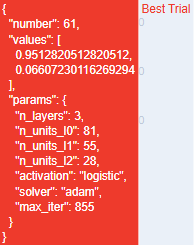

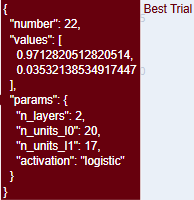

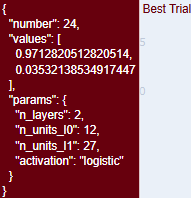

## Загрузка балансированных данных для ообучения на лучших параметрах

In [ ]:
import joblib
from imblearn.over_sampling import SMOTE, ADASYN

scaler = joblib.load("backups/scaler.pkl")

X, Y = np.array(df[V1_name + V3_name]), np.array(df[target_name]).flatten()
X_norm = scaler.fit_transform(X)
smote = SMOTE(random_state=42)
X_bal, Y_bal = smote.fit_resample(X_norm, Y)

## Загрузка контрольной выборки и предобработка

In [75]:
df_c = pd.read_excel(settings.data_path.test_dir)
df_c

,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,V2real,V3real,N1,N2,N3,Type
0,1.143286,0.016591,1.073907,0.343529,-0.032941,0.185294,0.018899,-0.003246,0.004323,-254.117647,0.000000,257.294118,-5081,-2,5062,1
1,0.499246,1.135747,0.481146,0.654118,0.263529,-1.826471,0.009004,-0.015884,-0.007669,162.000000,-308.117647,154.058824,2952,-5933,2991,1
2,0.351433,0.874811,0.942685,0.845882,0.114118,-3.032941,0.016070,-0.034309,-0.008215,-111.176471,-327.176471,462.176471,-2065,-6018,8444,1
3,0.333333,0.459566,0.258382,0.533077,-1.130769,16.233077,-0.008263,0.007343,0.021297,157.846154,162.000000,170.307692,3503,3338,3533,1
4,0.347008,0.353846,0.336752,0.093333,-1.026667,34.422667,-0.003776,-0.000049,0.003906,360.000000,352.800000,349.200000,5917,5931,5939,1
5,0.350961,0.451923,0.437500,-0.688750,-5.436250,76.135000,0.009110,0.022644,0.087982,759.375000,762.750000,767.812500,13176,13081,13128,1
6,0.505983,0.003419,0.288889,0.724000,0.322000,0.722667,-0.001660,0.006966,0.002360,-291.600000,1.800000,300.600000,-4703,6,4877,2
7,0.224359,0.278846,0.174679,0.560625,0.382500,0.042500,-0.009125,-0.019577,0.008163,168.750000,-356.062500,180.562500,3007,-6222,3059,2
8,0.225641,0.283760,0.280342,0.378667,0.157333,1.321333,0.008350,0.009814,0.001465,-113.400000,-354.600000,484.200000,-2035,-6223,8546,2
9,0.282051,0.331624,0.099145,0.541333,-0.878667,20.526667,0.002083,-0.017399,-0.005501,167.400000,165.600000,187.200000,2732,2726,2953,2


In [76]:
df_c['Type'] = (df_c['Type'] == 4).astype(int)

# Применяем функцию к DataFrame
new_columns = df_c.apply(process_row, axis=1)

# Соединяем с исходным DF
df_c = pd.concat([df_c, new_columns], axis=1)

df_c['Tx'] = df_c['vx'] / df_c["curr_x"]
# df_c['Ty'] = df_c['vy'] / df_c["curr_y"]
df_c['Ty'] = 0.0
df_c['T_total'] = df_c['v_omega'] / df_c["curr_total"]
df_c['Tz'] = df_c['gz'] / df_c["curr_total"]

X_c, Y_c = np.array(df_c[V1_name + V3_name]), np.array(df_c[target_name]).flatten()
X_c_norm = scaler.transform(X_c)

X_c_norm, Y_c

(array([[ 8.32965720e-01,  1.06280209e-02,  8.74956917e-01,
          6.37350184e-01,  6.65287699e-01,  4.81813900e-02,
          4.93666405e-01,  4.68480738e-01,  5.90964864e-01,
          2.15880526e-02,  3.50628311e-01,  3.51018734e-01,
          2.08147796e-01,  0.00000000e+00,  1.04672882e-01,
          1.59126807e-02],
        [ 3.47776597e-01,  7.27536800e-01,  3.78578116e-01,
          6.49129777e-01,  6.97083348e-01,  2.63330270e-02,
          4.32344634e-01,  4.03830359e-01,  5.32334431e-01,
          4.17516881e-01,  9.09409344e-02,  2.09421578e-01,
          3.16368335e-01,  0.00000000e+00,  1.28990183e-01,
          6.02667867e-03],
        [ 2.36421223e-01,  5.60386647e-01,  7.65071353e-01,
          6.56402783e-01,  6.81059350e-01,  1.32303976e-02,
          4.76133438e-01,  3.09572875e-01,  5.29666190e-01,
          1.70240032e-01,  8.72192303e-02,  5.82250786e-01,
          1.93187658e-01,  0.00000000e+00,  1.73343830e-01,
          7.46833738e-03],
        [ 2.2278592

In [79]:
params = {
    'hidden_layer_sizes': (20, 20),
    'activation': 'logistic',
    'solver': 'lbfgs',
    'max_iter': 1800,
    'random_state': 42
}

clf = MLPClassifier(**params)
clf.fit(X_c_norm, Y_c)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(20, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'logistic'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'lbfgs'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1800
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [80]:
scores = cross_val_score(clf, X_norm, Y, cv=5, scoring='f1')
print(scores.mean(), scores.std())

0.9712820512820514 0.03532138534917447


In [82]:
Y_pred_c = clf.predict(X_c_norm) # Только predict, без fit [cite: 165]

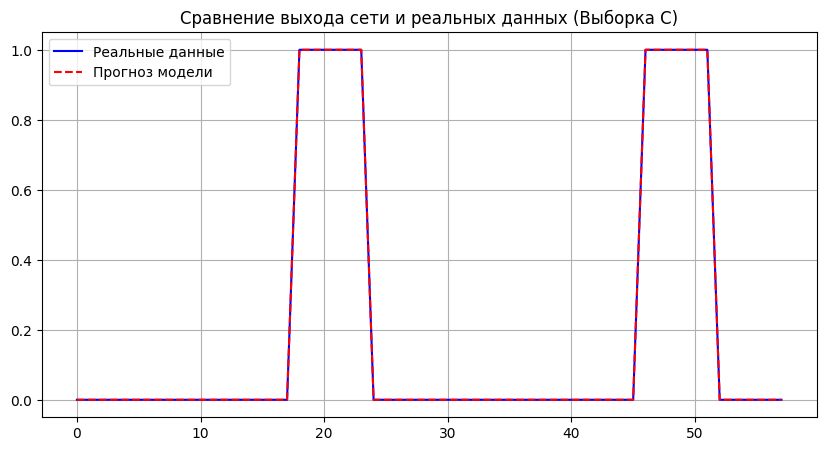

In [95]:
plt.figure(figsize=(10, 5))
plt.plot(Y_c, 'b-', label='Реальные данные')
plt.plot(Y_pred_c, 'r--', label='Прогноз модели')
plt.title('Сравнение выхода сети и реальных данных (Выборка С)')
plt.grid()
plt.legend()

plt.show()
plt.savefig("reports/comparison_plot.png")
plt.close()